# Self Learning Assignment: regional_sales_data

Name: Abhinav Gadekar     PRN: 260840128003 

Name Satyam Aggarwal      PRN: 260840128041

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sys

In [15]:
df = pd.read_csv('regional_sales_data.txt',sep=' ')
df.head()   

,Region_ID,Units_Sold,Unit_Price,Store_name,Country
0,REG_01,NaN,34.75,Beta_Retail,UK
1,REG_01,149.0,17.82,Delta_Shop,India
2,REG_01,NaN,30.94,Epsilon_Hub,India
3,REG_02,149.0,47.75,Delta_Shop,Canada
4,REG_03,11.0,78.29,Beta_Retail,Germany


1. Check and replace all missing values in the Units_Sold column with the
median value of that specific column

In [16]:
med = np.median(df['Units_Sold'].dropna())
print(f'median is {med}')
df['Units_Sold'] = df['Units_Sold'].fillna(med)

# firstly find median of units sold by removing null values 
#                   |
#                   v
#  Then filled null values with median value

median is 100.0


2. Calculate the total units sold and the average unit price for each Store_name.
Identify which store has generated the highest total units sold

In [17]:
df_agg = df.groupby('Store_name').agg({ 'Unit_Price':['mean' ],'Units_Sold':['sum'] }).reset_index()
print(df_agg)
df_agg.columns = ['Store_name','Price Average','Total Units Sold']
df_agg

#  firstly grouped dataset with Store_name  
#  then applied mean function on Unit_Price column, and sum on  Units Sold

    Store_name Unit_Price Units_Sold
                     mean        sum
0   Alpha_Mart  62.286667      881.0
1  Beta_Retail  59.816667     1042.0
2   Delta_Shop  40.494000     1001.0
3  Epsilon_Hub  59.321333     1376.0
4  Gamma_Store  55.271818     1057.0


,Store_name,Price Average,Total Units Sold
0,Alpha_Mart,62.286667,881.0
1,Beta_Retail,59.816667,1042.0
2,Delta_Shop,40.494000,1001.0
3,Epsilon_Hub,59.321333,1376.0
4,Gamma_Store,55.271818,1057.0


In [18]:
df_agg[df_agg['Total Units Sold']== max(df_agg['Total Units Sold'])]

# done filtering of Total Units Sold by maximum value Total Units Sold

,Store_name,Price Average,Total Units Sold
3,Epsilon_Hub,59.321333,1376.0


In [19]:
df.head(2)

,Region_ID,Units_Sold,Unit_Price,Store_name,Country
0,REG_01,100.0,34.75,Beta_Retail,UK
1,REG_01,149.0,17.82,Delta_Shop,India


3. Create a new column named Total_Revenue, calculated by multiplying
Units_Sold by Unit_Price

In [20]:
df['Total_Revenue'] = df['Units_Sold'] * df['Unit_Price']

''' 
extracted Units_Sold and Unit_Price series
then  cal  multiply them
stored in total_revenue series column of df
'''

' \nextracted Units_Sold and Unit_Price series\nthen  cal  multiply them\nstored in total_revenue series column of df\n'

In [21]:
df.head()

,Region_ID,Units_Sold,Unit_Price,Store_name,Country,Total_Revenue
0,REG_01,100.0,34.75,Beta_Retail,UK,3475.00
1,REG_01,149.0,17.82,Delta_Shop,India,2655.18
2,REG_01,100.0,30.94,Epsilon_Hub,India,3094.00
3,REG_02,149.0,47.75,Delta_Shop,Canada,7114.75
4,REG_03,11.0,78.29,Beta_Retail,Germany,861.19


4. Group the data by Region_ID and calculate the sum of Total_Revenue for
each region

In [22]:
''' 
drop null values of total revenue
then group by region id
calculate sum of total revenue for each group 
reset index of group and add columns so they can be read easily
 '''

df_agg = df.groupby('Region_ID').agg({'Total_Revenue':['sum']}).reset_index()

df_agg.columns = ['Region_ID', 'Total_Revenue']
df_agg


,Region_ID,Total_Revenue
0,REG_01,117092.28
1,REG_02,63404.82
2,REG_03,62422.10
3,REG_04,52051.47


5. Use Matplotlib to plot a bar chart showing Region_ID on the x-axis and the
sum of Total_Revenue on the y-axis. Set the bar colour to green, add a grid
on the y-axis, and give the chart a clear title


In [23]:
df.head()

,Region_ID,Units_Sold,Unit_Price,Store_name,Country,Total_Revenue
0,REG_01,100.0,34.75,Beta_Retail,UK,3475.00
1,REG_01,149.0,17.82,Delta_Shop,India,2655.18
2,REG_01,100.0,30.94,Epsilon_Hub,India,3094.00
3,REG_02,149.0,47.75,Delta_Shop,Canada,7114.75
4,REG_03,11.0,78.29,Beta_Retail,Germany,861.19


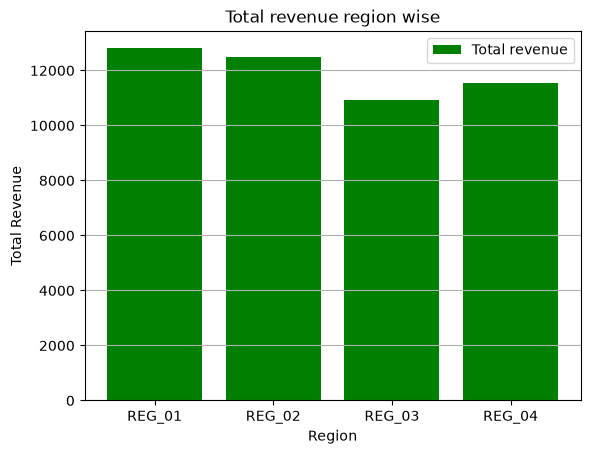

'  \nThis graph shows region on x axis and total revenue on y axis\nthen set title, added with xlabel and ylabel\n'

In [24]:
 
plt.bar(df['Region_ID'],df['Total_Revenue'] , label='Total revenue',color='green' )
plt.grid(axis='y')
plt.legend()
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.title('Total revenue region wise')
plt.show()

'''  
This graph shows region on x axis and total revenue on y axis
then set title, added with xlabel and ylabel
'''

6. Create a scatter plot using Matplotlib mapping Unit_Price on the x-axis
against Units_Sold on the y-axis

'  \nThis graph shows unit price on x axis and unit sold on y axis\nthen set title, added with xlabel and ylabel\n'

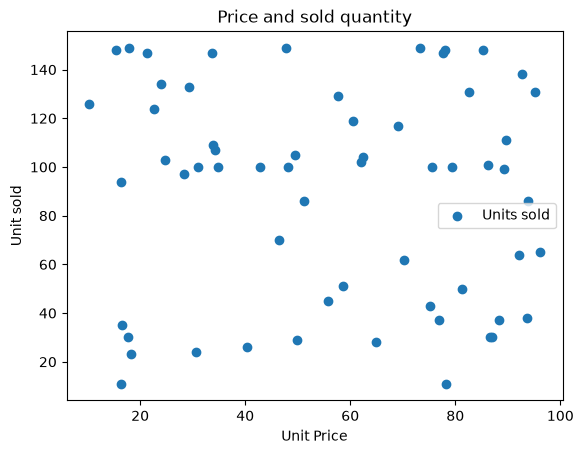

In [25]:
plt.scatter(x = df['Unit_Price'],y= df['Units_Sold'], label='Units sold')
plt.xlabel('Unit Price')
plt.title('Price and sold quantity')
plt.legend()
plt.ylabel('Unit sold')

'''  
This graph shows unit price on x axis and unit sold on y axis
then set title, added with xlabel and ylabel
'''